# 01 · Exploratory Data Analysis

**Telco Customer Churn** - 7,043 customers, 21 columns. Goal: understand *who*
churns before we model *whether* they will.

This notebook uses the project's `churn` package so the loading/cleaning logic
is identical to the app and the tests.

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid", palette="deep")

from churn import config, data

raw = data.load_raw()
df = data.load_clean()
print("shape:", df.shape)
df.head()

shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,No,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,5575-GNVDE,Male,No,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,3668-QPYBK,Male,No,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,7795-CFOCW,Male,No,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,9237-HQITU,Female,No,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


## Target balance
Churn is imbalanced - about a quarter of customers leave.

overall churn rate: 26.5%


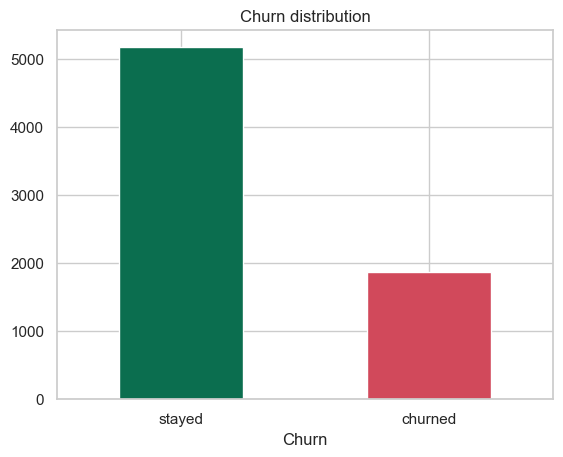

In [2]:
rate = df[config.TARGET].mean()
print(f"overall churn rate: {rate:.1%}")
df[config.TARGET].value_counts().rename({0: "stayed", 1: "churned"}).plot.bar(
    color=["#0b6e4f", "#d1495b"], rot=0, title="Churn distribution"
);

## Missing values

`TotalCharges` ships as text and is **blank** for the 11 brand-new customers
whose `tenure` is 0. These become genuine missing values - feature engineering
adds a binary flag for them (notebook 02).

In [3]:
blanks = raw["TotalCharges"].str.strip().eq("").sum()
print("blank TotalCharges rows:", blanks)
print("tenure of those rows:", raw.loc[raw["TotalCharges"].str.strip().eq(""), "tenure"].unique())

blank TotalCharges rows: 11
tenure of those rows: [0]


## Churn by contract type
Month-to-month customers churn several times more than contract customers.

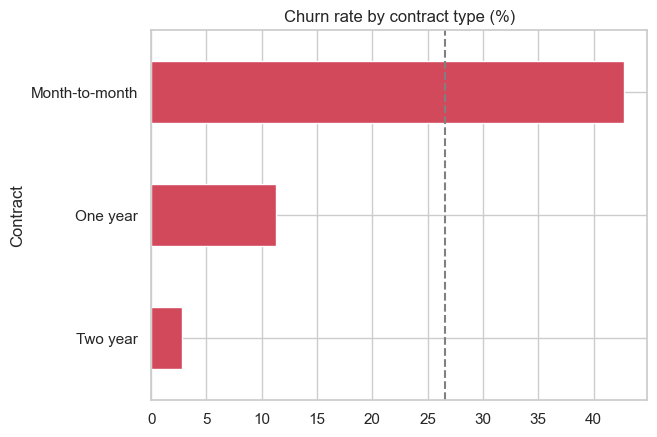

In [4]:
ax = (df.groupby("Contract")[config.TARGET].mean() * 100).sort_values().plot.barh(
    color="#d1495b", title="Churn rate by contract type (%)"
)
ax.axvline(df[config.TARGET].mean() * 100, ls="--", c="gray");

## Churn by tenure
Risk is highest in the first year and decays with tenure.

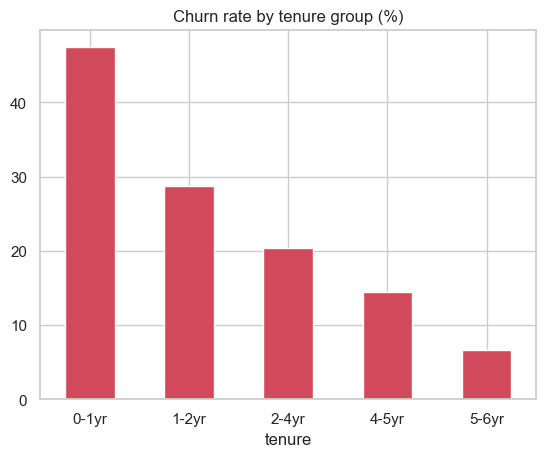

In [5]:
import pandas as pd
tb = pd.cut(df["tenure"], bins=[-0.1, 12, 24, 48, 60, 72],
            labels=["0-1yr", "1-2yr", "2-4yr", "4-5yr", "5-6yr"])
(df.groupby(tb, observed=True)[config.TARGET].mean() * 100).plot.bar(
    color="#d1495b", rot=0, title="Churn rate by tenure group (%)"
);

## Churn by payment method & internet service

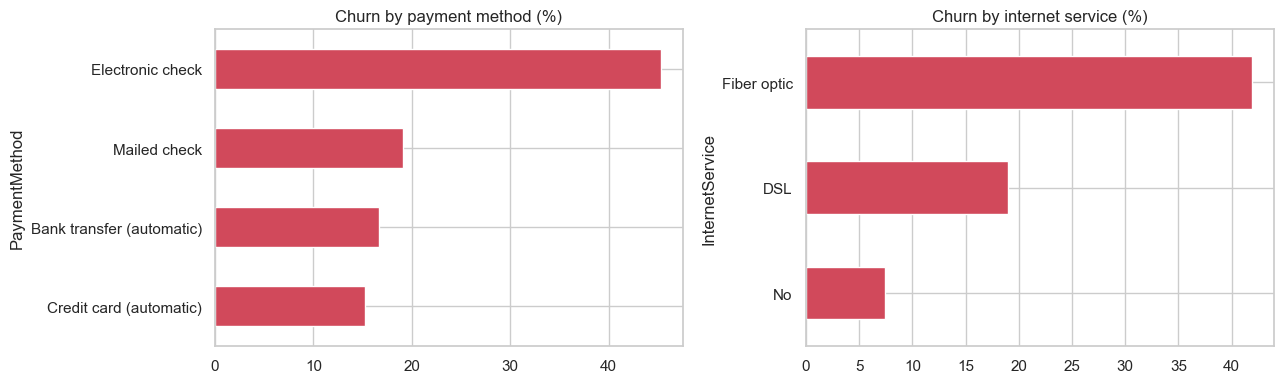

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
(df.groupby("PaymentMethod")[config.TARGET].mean() * 100).sort_values().plot.barh(
    color="#d1495b", ax=axes[0], title="Churn by payment method (%)")
(df.groupby("InternetService")[config.TARGET].mean() * 100).sort_values().plot.barh(
    color="#d1495b", ax=axes[1], title="Churn by internet service (%)")
plt.tight_layout();

## Monthly charges vs churn
Churners skew towards higher monthly charges.

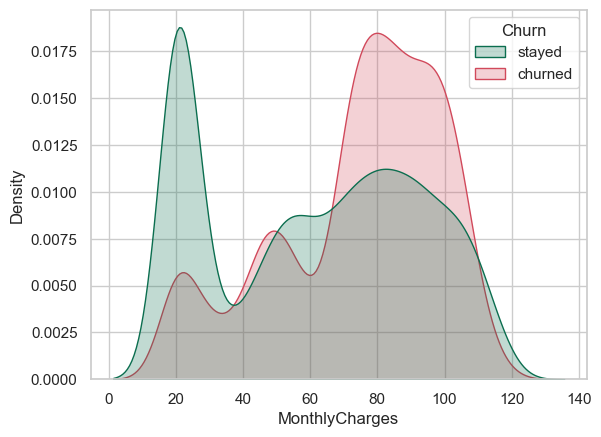

In [7]:
sns.kdeplot(data=df, x="MonthlyCharges", hue=df[config.TARGET].map({0: "stayed", 1: "churned"}),
            fill=True, common_norm=False, palette=["#0b6e4f", "#d1495b"]);

## Takeaways

- **Month-to-month contracts** and **short tenure** are the strongest churn
  signals - exactly what the model and SHAP analysis confirm later.
- **Electronic-check** payers and **fiber-optic** customers churn more.
- Churners tend to pay **higher monthly charges**.

Next: turn these observations into engineered features → `02_feature_engineering`.